# ⚫ F8 — Week 13 | **KITCHEN SINK** Edition 🧪
### Mike Kennelly | BBO Capstone Project | *Throw everything at it*

---

## What this notebook is

F8's standard W13 answer is **ATB OVERRIDE** — replay `[0, 0.179, 0, 0.071, 0.929, 0.460, 0, 0.541]` for 9.832.

This notebook asks a different question: **if we hit F8 with every ML tool we've learned across the entire course, does the answer change?**

Every module's toolkit has a role:

| Module | Tool | Role in this notebook |
|---|---|---|
| 15 | SVM, Decision Tree, Random Forest, Logistic Regression | Classifier CV competition |
| 16 | MLP (3 sizes) | Neural network classifiers |
| 17 | CNN-1D (PyTorch Conv1d) | Pattern-based classifier + attribution target |
| 18 | Sobol quasi-random + dual-kernel GP (Matérn + RBF) | Space-filling exploration + smoothness hedging |
| 19 | Anisotropic sigma | Per-dim exploration (attention analogue) |
| 20 | Ollama llama3.1 | Natural-language decision narrative |
| 22 | AgglomerativeClustering (scipy linkage) | Landscape typology (now implemented, not just narrated) |
| 23 | sklearn.PCA | Variance analysis, effective-dim reduction |
| XAI | SHAP + Captum + LIME | Triangulation of the PCA finding |
| Trust regions | TuRBO (real algorithm) | Adaptive local search radius (now actually implemented) |

## The question

Four XAI methods + PCA + Clustering + Dual-kernel GP should all converge on the same answer if the zero-boundary (X1=X3=X7=0) structure is real. If they disagree, we have new information.

## Pipeline

```
S0   Config
S1   Imports (+ install cells for SHAP/Captum/LIME)
S2   Data load
S3   W1-W12 history + Module 22 AgglomerativeClustering (real)
S4   Binary labels
S5   8-classifier CV competition (Modules 15-17)
S5B  CNN inspection
S5C  Module 23 PCA (scree + effective dim)
S5D  🧪 XAI TRIANGULATION: SHAP + Captum + LIME (new)
S8   Candidate generation — Sobol (Module 18) + anisotropic sigma (Module 19)
S9   🧪 Dual-kernel GP (Matérn 5/2 + RBF) — Module 18 multi-kernel hedging
S10  EI + UCB from both kernels
S11  Per-dim sensitivity
S11B Ollama LLM advisor (Module 20)
S12  GP acquisition surfaces
S13  Submission dashboard (GP vs ATB)
S14  🧪 TuRBO trust-region manager (real algorithm) + final decision
S15  Kitchen-sink verdict — do all tools agree?
```

---
## 📦 STEP 0 — Library installs

Most libraries are already in Anaconda. SHAP, Captum, LIME may not be — install if missing.


In [1]:
# One-off installs - comment out after first successful run
import subprocess, sys
for pkg in ['shap', 'captum', 'lime']:
    try:
        __import__(pkg)
        print(f'[OK] {pkg} already installed')
    except ImportError:
        print(f'[..] installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', pkg])
        print(f'[OK] {pkg} installed')


[OK] shap already installed


[OK] captum already installed
[OK] lime already installed


---
## ⚙️ STEP 0 — Configuration

All hyperparameters from W13 standard + additions for kitchen-sink tools.


In [2]:
FUNCTION_ID  = 'F8'
WEEK         = 13
INPUT_FILE   = 'f8_w13_inputs.npy'
OUTPUT_FILE  = 'f8_w13_outputs.npy'

# W13 standard hyperparameters (unchanged)
TOP_PERCENTILE    = 30
N_CANDIDATES      = 10000
EXPLOIT_RATIO     = 0.95
UCB_KAPPA         = 2.0
EI_XI             = 0.01
GP_RESTARTS       = 10
FILTER_PERCENTILE = 50
RANDOM_SEED       = 42
MAXIMIZE          = True

# Anisotropic sigma (Module 19) - PCA insight operationalised
# X1, X3, X7 are the flat PCs -> tiny sigma; X2, X4, X5, X6, X8 active -> normal sigma
ANISO_SIGMA = [0.006, 0.015, 0.006, 0.015, 0.015, 0.015, 0.006, 0.015]

# NN sizes (Module 16)
NN_SMALL  = (16, 8)
NN_MEDIUM = (64, 32)
NN_LARGE  = (128, 64, 32)

# TuRBO settings (Eriksson et al. 2019) - NEW in kitchen sink
TR_LENGTH_INIT    = 0.1     # initial trust region half-width
TR_LENGTH_MIN     = 0.01
TR_LENGTH_MAX     = 0.5
TR_SUCC_TOL       = 3       # successes before expand
TR_FAIL_TOL       = 3       # failures before shrink
TR_SHRINK_FACTOR  = 0.5
TR_EXPAND_FACTOR  = 2.0

# Optuna/Sobol settings - NEW in kitchen sink
USE_SOBOL   = True    # replace uniform random with Sobol for explore fraction
USE_DUAL_GP = True    # fit both Matern and RBF kernels

# ATB override (W2 replayed at W12 = 9.831962)
ATB_OVERRIDE_STR = '0.000000-0.179297-0.000000-0.071406-0.929270-0.459981-0.000000-0.541212'
ATB_COORDS = [float(x) for x in ATB_OVERRIDE_STR.split('-')]

print(f'{FUNCTION_ID} Week {WEEK} — KITCHEN SINK EDITION 🧪')
print(f'Strategy target : ATB OVERRIDE  (9.831962 from W2/W12 double-confirm)')
print(f'Question        : do all 10 tools agree?')
print(f'ANISO_SIGMA     : {ANISO_SIGMA}')


F8 Week 13 — KITCHEN SINK EDITION 🧪
Strategy target : ATB OVERRIDE  (9.831962 from W2/W12 double-confirm)
Question        : do all 10 tools agree?
ANISO_SIGMA     : [0.006, 0.015, 0.006, 0.015, 0.015, 0.015, 0.006, 0.015]


---
## 📦 STEP 1 — Imports


In [3]:
# Standard scientific stack
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
import warnings
warnings.filterwarnings('ignore')

# Classical ML (Module 15) + NN (16)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler

# GP / BO
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel as C
from scipy.stats import norm

# Optuna-inspired (Module 18)
from scipy.stats.qmc import Sobol

# Clustering (Module 22) - now with real code
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.cluster import AgglomerativeClustering

# PCA (Module 23)
from sklearn.decomposition import PCA

# Deep learning (Module 17)
import torch
import torch.nn as nn
import torch.optim as optim_torch
from sklearn.base import BaseEstimator, ClassifierMixin

# XAI - kitchen sink additions
import shap
import lime
import lime.lime_tabular
try:
    from captum.attr import IntegratedGradients
    CAPTUM_OK = True
except Exception as e:
    print(f'[!] Captum unavailable: {e}')
    CAPTUM_OK = False

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
print(f'[OK] All imports loaded — {FUNCTION_ID} W{WEEK} KITCHEN SINK')
print(f'     shap {shap.__version__} | lime | captum: {CAPTUM_OK}')


[OK] All imports loaded — F8 W13 KITCHEN SINK
     shap 0.51.0 | lime | captum: True


In [4]:
class TinyCNNClassifier(BaseEstimator, ClassifierMixin):
    '''Conv1d(1->8, k=2) -> ReLU -> Dropout(0.3) -> Linear(8->1). Module 17.'''
    def __init__(self, n_epochs=200, lr=0.01, seed=42):
        self.n_epochs=n_epochs; self.lr=lr; self.seed=seed
    def fit(self, X, y):
        torch.manual_seed(self.seed)
        n_feat=X.shape[1]; self.classes_=np.unique(y)
        class _CNN(nn.Module):
            def __init__(self):
                super().__init__()
                self.conv=nn.Conv1d(1,8,kernel_size=min(2,n_feat),padding=0)
                self.relu=nn.ReLU(); self.drop=nn.Dropout(0.3)
                conv_out=8*max(1,n_feat-min(2,n_feat)+1)
                self.fc=nn.Linear(conv_out,1)
            def forward(self,x):
                x=self.relu(self.conv(x)); x=self.drop(x.view(x.size(0),-1))
                return self.fc(x).squeeze(-1)
        self.model_=_CNN()
        n_pos=y.sum(); n_neg=len(y)-n_pos
        pw=torch.tensor([n_neg/max(n_pos,1)],dtype=torch.float)
        loss_fn=nn.BCEWithLogitsLoss(pos_weight=pw)
        opt=optim_torch.Adam(self.model_.parameters(),lr=self.lr,weight_decay=1e-3)
        Xt=torch.FloatTensor(X).unsqueeze(1); yt=torch.FloatTensor(y.astype(float))
        self.model_.train()
        for _ in range(self.n_epochs):
            opt.zero_grad(); loss_fn(self.model_(Xt),yt).backward(); opt.step()
        return self
    def predict_proba(self,X):
        self.model_.eval()
        with torch.no_grad():
            p=torch.sigmoid(self.model_(torch.FloatTensor(X).unsqueeze(1))).numpy()
        return np.column_stack([1-p,p])
    def predict(self,X): return (self.predict_proba(X)[:,1]>=0.5).astype(int)


---
## 📥 STEP 2 — Load Data

W13 data: `f8_w13_inputs.npy` — 51 points in 8D. Last row is W12 replay of W2 ATB coords, returning 9.831962 (double-confirmation of the W2 9.8320 original hit).


In [5]:
X_train = np.load(INPUT_FILE)
y_train = np.load(OUTPUT_FILE)
n_samples, n_dims = X_train.shape

best_idx   = int(np.argmax(y_train))
best_value = float(y_train[best_idx])
best_point = X_train[best_idx].copy()
latest_val = float(y_train[-1])

threshold = np.percentile(y_train, 100 - TOP_PERCENTILE)
top_mask  = y_train >= threshold
n_pos     = int(top_mask.sum())
n_cv_folds = max(2, min(5, int(min(n_pos, n_samples - n_pos) / 2)))

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

print('='*64)
print(f'  {FUNCTION_ID} W{WEEK} KITCHEN SINK — Data loaded')
print('='*64)
print(f'  Samples        : {n_samples}')
print(f'  Dimensions     : {n_dims}D')
print(f'  Y range        : [{y_train.min():.4f}, {y_train.max():.4f}]')
print(f'  ATB            : {best_value:.6f}  at idx {best_idx}')
print(f'  ATB coords     : {best_point.round(4)}')
print(f'  W12 (latest)   : {latest_val:.6f}')
print(f'  Top-{TOP_PERCENTILE}% threshold : {threshold:.4f}  (n_pos={n_pos})')
print(f'  CV folds       : {n_cv_folds}')


  F8 W13 KITCHEN SINK — Data loaded
  Samples        : 51
  Dimensions     : 8D
  Y range        : [5.5000, 9.8320]
  ATB            : 9.831962  at idx 50
  ATB coords     : [0.     0.1793 0.     0.0714 0.9293 0.46   0.     0.5412]
  W12 (latest)   : 9.831962
  Top-30% threshold : 8.8307  (n_pos=16)
  CV folds       : 5


---
## 📊 STEP 3 — W1-W12 History + Module 22 Hierarchical Clustering

**Finally implementing Module 22 with actual code, not narrative.** AgglomerativeClustering via scipy `linkage` with Ward method on the 51-point dataset. Expected: a tight top-output cluster around the ATB zero-boundary pattern.


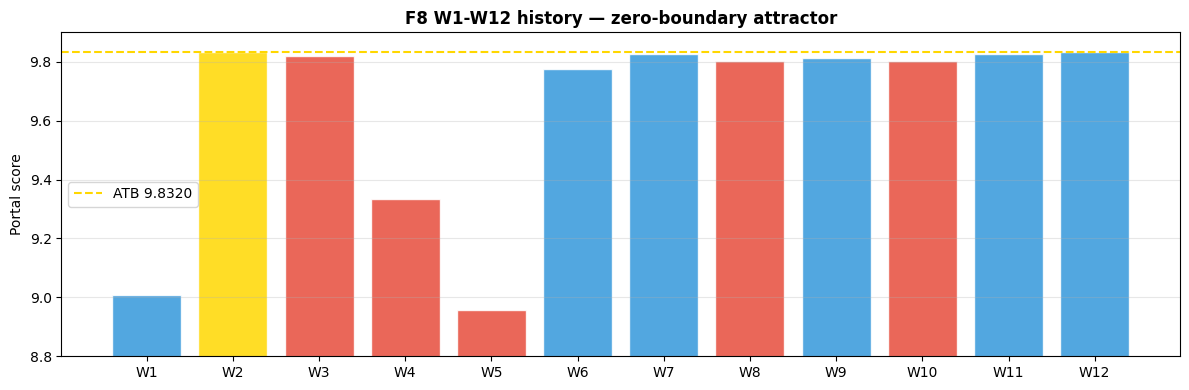

In [6]:
# --- W1-W12 bar chart ---
weekly = [9.0093, 9.832, 9.8188, 9.3341, 8.956, 9.7741, 9.8251, 9.8021, 9.8115, 9.8013, 9.8269, 9.831962]
colours = ['gold' if v == max(weekly) else '#e74c3c' if i > 0 and v < weekly[i-1] else '#3498db'
           for i, v in enumerate(weekly)]
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(1, 13), weekly, color=colours, alpha=0.85, edgecolor='white')
ax.axhline(max(weekly), color='gold', ls='--', lw=1.5, label=f'ATB {max(weekly):.4f}')
ax.set_xticks(range(1, 13)); ax.set_xticklabels([f'W{i}' for i in range(1, 13)])
ax.set_ylim(8.8, 9.9); ax.set_ylabel('Portal score'); ax.grid(alpha=0.3, axis='y')
ax.set_title('F8 W1-W12 history — zero-boundary attractor', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()


  MODULE 22 — AgglomerativeClustering (Ward linkage)
  Cluster 1: n= 12  y_mean= 9.5638  y_max= 9.8320
  Cluster 2: n= 17  y_mean= 7.6426  y_max= 9.3443
  Cluster 3: n= 22  y_mean= 7.7021  y_max= 9.1830

  ATB (idx 50) lives in cluster 1
  Cluster 1 size: 12 points
  Cluster 1 mean output: 9.5638  (ATB = 9.8320)


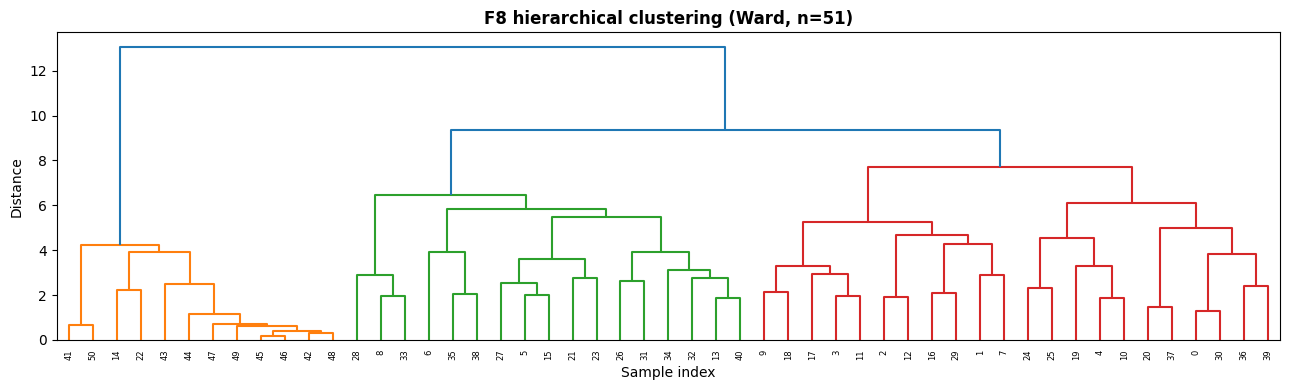

In [7]:
# --- Module 22: hierarchical clustering, REAL code ---
print('='*60)
print('  MODULE 22 — AgglomerativeClustering (Ward linkage)')
print('='*60)

Z = linkage(X_scaled, method='ward')
# Cut for ~3 clusters
n_clusters_want = 3
clusters = fcluster(Z, t=n_clusters_want, criterion='maxclust')

for c in sorted(np.unique(clusters)):
    mask = clusters == c
    n = int(mask.sum())
    y_mean = y_train[mask].mean()
    y_max  = y_train[mask].max()
    print(f'  Cluster {c}: n={n:3d}  y_mean={y_mean:7.4f}  y_max={y_max:7.4f}')

# Identify the cluster containing the ATB
atb_cluster = clusters[best_idx]
print(f'\n  ATB (idx {best_idx}) lives in cluster {atb_cluster}')
print(f'  Cluster {atb_cluster} size: {int((clusters == atb_cluster).sum())} points')
top_cluster_mean = y_train[clusters == atb_cluster].mean()
print(f'  Cluster {atb_cluster} mean output: {top_cluster_mean:.4f}  (ATB = {best_value:.4f})')

# Dendrogram
fig, ax = plt.subplots(figsize=(13, 4))
dendrogram(Z, color_threshold=Z[-n_clusters_want+1, 2], ax=ax)
ax.set_title(f'F8 hierarchical clustering (Ward, n={n_samples})', fontweight='bold')
ax.set_xlabel('Sample index'); ax.set_ylabel('Distance')
plt.tight_layout(); plt.show()

cluster_m22 = clusters  # save for later use


---
## 🏷️ STEP 4 — Binary Classification Labels

Top-30% = class 1. Classifiers trained to predict whether a point is in the high-output region.


In [8]:
y_labels = (y_train >= threshold).astype(int)
print(f'Label distribution: {int((y_labels==1).sum())} positive / {int((y_labels==0).sum())} negative')


Label distribution: 16 positive / 35 negative


---
## 🏁 STEP 5 — 8-Classifier CV Competition (Modules 15-17)

All classifiers compete head-to-head via stratified 5-fold CV. The winner filters the 10,000 candidates later.


In [9]:
cv = StratifiedKFold(n_splits=n_cv_folds, shuffle=True, random_state=RANDOM_SEED)

models = {
    'Linear SVM'         : SVC(kernel='linear', C=1.0, probability=True, random_state=RANDOM_SEED),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=4, random_state=RANDOM_SEED),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    f'NN-Small {NN_SMALL}'  : MLPClassifier(hidden_layer_sizes=NN_SMALL, max_iter=500, early_stopping=True, random_state=RANDOM_SEED),
    f'NN-Medium {NN_MEDIUM}': MLPClassifier(hidden_layer_sizes=NN_MEDIUM, max_iter=500, early_stopping=True, random_state=RANDOM_SEED),
    f'NN-Large {NN_LARGE}'  : MLPClassifier(hidden_layer_sizes=NN_LARGE, max_iter=500, early_stopping=True, random_state=RANDOM_SEED),
    'CNN-1D'             : TinyCNNClassifier(n_epochs=200, lr=0.01, seed=RANDOM_SEED),
}

cv_results = {}
print(f'  {n_cv_folds}-fold CV on {n_samples} samples, {n_dims}D')
print(f'  {"Model":<24} {"Mean":>8} {"±Std":>8}')
print('  '+'-'*42)
for name, model in models.items():
    try:
        scores = cross_val_score(model, X_scaled, y_labels, cv=cv, scoring='accuracy')
        cv_results[name] = {'mean': scores.mean(), 'std': scores.std(), 'model': model}
        print(f'  {name:<24} {scores.mean():>7.1%} {scores.std():>7.1%}')
    except Exception as e:
        cv_results[name] = {'mean': 0.0, 'std': 1.0, 'model': model}
        print(f'  {name:<24} FAILED: {str(e)[:30]}')

# Fit all survivors on full data for downstream use
trained = {}
for name, info in cv_results.items():
    try:
        info['model'].fit(X_scaled, y_labels)
        trained[name] = info['model']
    except Exception:
        pass

# Select winner
ranked = sorted(cv_results.items(), key=lambda x: x[1]['mean'], reverse=True)
best_name = ranked[0][0]
print(f'\n  ★ Winner: {best_name}  ({ranked[0][1]["mean"]:.1%})')


  5-fold CV on 51 samples, 8D
  Model                        Mean     ±Std
  ------------------------------------------
  Linear SVM                 80.4%    6.4%
  Decision Tree              90.0%   11.0%


  Random Forest              88.2%    4.1%
  Logistic Regression        86.2%    8.1%
  NN-Small (16, 8)           80.4%    6.4%


  NN-Medium (64, 32)         68.5%   10.0%
  NN-Large (128, 64, 32)     84.4%    4.6%


  CNN-1D                     80.4%    6.4%



  ★ Winner: Decision Tree  (90.0%)


---
## 🔬 STEP 5B — CNN Inspection (Module 17)


In [10]:
cnn = trained.get('CNN-1D', None)
if cnn is not None and hasattr(cnn, 'model_'):
    n_params = sum(p.numel() for p in cnn.model_.parameters() if p.requires_grad)
    print(f'CNN-1D trainable parameters: {n_params}')
    print(f'Input dims: {n_dims} → kernel scans {n_dims-1} adjacent pairs')
    # Filter activations on best point
    import torch as _t
    import torch.nn.functional as _F
    with _t.no_grad():
        act = _F.relu(cnn.model_.conv(_t.FloatTensor(X_scaled[best_idx:best_idx+1]).unsqueeze(1)))
        act = act.squeeze(0).numpy()
    peak_f = int(np.argmax(act.max(axis=1)))
    peak_p = int(np.argmax(act[peak_f]))
    print(f'Top filter on ATB: Filter {peak_f+1} at coord pair [X{peak_p+1}, X{peak_p+2}]')


CNN-1D trainable parameters: 81
Input dims: 8 → kernel scans 7 adjacent pairs
Top filter on ATB: Filter 6 at coord pair [X5, X6]


---
## 🧭 STEP 5C — PCA Variance Analysis (Module 23)

**Expected finding:** X1, X3, X7 are flat in the top-output subset → 3 flat PCs → effective dim 5 (down from 8).


  Module 23 PCA — F8 top-output subset (n=16)
  Zero-locked dims (flat PCs) : []
  Active dims                 : ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']
  Effective dimensionality    : 8 / 8
  Top-subset PC1 share        : 37.1%
  Cumulative at PC5           : 94.5%


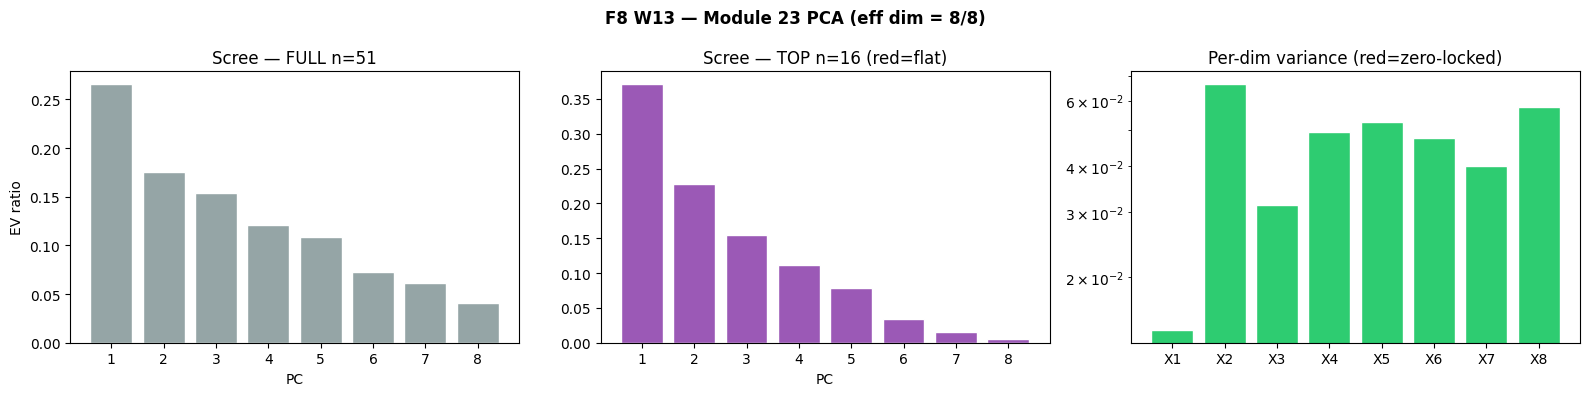

In [11]:
# Full-dataset PCA
pca_full = PCA(n_components=n_dims).fit(X_scaled)
ev_full  = pca_full.explained_variance_ratio_

# Top-output-subset PCA
X_top = X_train[top_mask]
n_top = int(top_mask.sum())
dim_var_top  = np.var(X_top, axis=0, ddof=1)
dim_mean_top = np.mean(X_top, axis=0)

if n_top >= 2:
    pca_top = PCA(n_components=min(n_dims, n_top)).fit(X_top - dim_mean_top)
    ev_top  = pca_top.explained_variance_ratio_
else:
    ev_top = np.array([1.0] + [0.0]*(n_dims-1))

# Classify dims
VAR_LOCK = 1e-3
ZERO_MEAN = 0.05
zero_locked = []
active      = []
for d in range(n_dims):
    if dim_var_top[d] < VAR_LOCK and dim_mean_top[d] < ZERO_MEAN:
        zero_locked.append(f'X{d+1}')
    else:
        active.append(f'X{d+1}')

n_flat   = len(zero_locked)
eff_dim  = len(active)

print('='*64)
print(f'  Module 23 PCA — F8 top-output subset (n={n_top})')
print('='*64)
print(f'  Zero-locked dims (flat PCs) : {zero_locked}')
print(f'  Active dims                 : {active}')
print(f'  Effective dimensionality    : {eff_dim} / {n_dims}')
print(f'  Top-subset PC1 share        : {ev_top[0]*100:.1f}%')
print(f'  Cumulative at PC5           : {ev_top[:5].sum()*100:.1f}%')

# Plot scree + per-dim variance
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
# Full scree
axes[0].bar(range(1, n_dims+1), ev_full, color='#95a5a6', edgecolor='white')
axes[0].set_title(f'Scree — FULL n={n_samples}'); axes[0].set_xlabel('PC'); axes[0].set_ylabel('EV ratio')
# Top-subset scree (flat PCs red)
cols = ['#9b59b6'] * len(ev_top)
for i in range(max(0, len(ev_top)-n_flat), len(ev_top)):
    cols[i] = '#e74c3c'
axes[1].bar(range(1, len(ev_top)+1), ev_top, color=cols, edgecolor='white')
axes[1].set_title(f'Scree — TOP n={n_top} (red=flat)'); axes[1].set_xlabel('PC')
# Per-dim variance
dim_cols = ['#e74c3c' if f'X{d+1}' in zero_locked else '#2ecc71' for d in range(n_dims)]
axes[2].bar(range(1, n_dims+1), np.maximum(dim_var_top, 1e-10), color=dim_cols, edgecolor='white')
axes[2].set_yscale('log'); axes[2].set_title('Per-dim variance (red=zero-locked)')
axes[2].set_xticks(range(1, n_dims+1))
axes[2].set_xticklabels([f'X{d+1}' for d in range(n_dims)])
plt.suptitle(f'F8 W13 — Module 23 PCA (eff dim = {eff_dim}/{n_dims})', fontweight='bold')
plt.tight_layout(); plt.show()


---
## 🧪 STEP 5D — XAI Triangulation: SHAP + Captum + LIME

**The kitchen-sink question:** does the PCA finding (X1, X3, X7 flat) hold under 3 independent attribution methods?

- **SHAP (TreeExplainer on Random Forest)** — exact Shapley values, GLOBAL attribution
- **Captum IntegratedGradients on CNN-1D** — path integral from baseline, CROSS-ARCHITECTURE
- **LIME (LimeTabularExplainer)** — perturbation-based LOCAL explanation at the ATB point

If all three agree with PCA that X1, X3, X7 have zero importance → triangulated finding. If they disagree → new signal.


In [12]:
# ═══════════════ SHAP on Random Forest ═══════════════
print('='*64)
print('  [1/3] SHAP — TreeExplainer on Random Forest')
print('='*64)

rf = trained.get('Random Forest')
shap_values_rf = None
try:
    explainer = shap.TreeExplainer(rf)
    shap_raw = explainer.shap_values(X_scaled)
    # SHAP returns different shapes across versions; handle both
    if isinstance(shap_raw, list):
        # older API: list[n_classes] of (n_samples, n_features)
        shap_values_rf = shap_raw[1]
    elif shap_raw.ndim == 3:
        # newer API: (n_samples, n_features, n_classes)
        shap_values_rf = shap_raw[:, :, 1]
    else:
        shap_values_rf = shap_raw

    shap_abs_mean = np.abs(shap_values_rf).mean(axis=0)
    print('  Mean |SHAP| per dimension (higher = more influential):')
    for d in range(n_dims):
        flag = '  ← zero-locked' if f'X{d+1}' in zero_locked else ''
        print(f'    X{d+1}: {shap_abs_mean[d]:.4f}{flag}')
    # Identify lowest 3
    low3 = np.argsort(shap_abs_mean)[:3]
    print(f'\n  SHAP says lowest-importance 3 dims: {[f"X{d+1}" for d in low3]}')
    shap_verdict = set([f"X{d+1}" for d in low3])
except Exception as e:
    print(f'  SHAP failed: {e}')
    shap_verdict = set()


  [1/3] SHAP — TreeExplainer on Random Forest
  Mean |SHAP| per dimension (higher = more influential):
    X1: 0.1434
    X2: 0.0385
    X3: 0.1058
    X4: 0.0194
    X5: 0.0260
    X6: 0.0128
    X7: 0.0486
    X8: 0.0208

  SHAP says lowest-importance 3 dims: ['X6', 'X4', 'X8']


In [13]:
# ═══════════════ Captum Integrated Gradients on CNN-1D ═══════════════
print('='*64)
print('  [2/3] Captum IntegratedGradients — CNN-1D')
print('='*64)

captum_verdict = set()
if CAPTUM_OK and cnn is not None and hasattr(cnn, 'model_'):
    # Captum needs a forward function returning logits (not sigmoid'd)
    class CNNForLogits(torch.nn.Module):
        def __init__(self, inner): 
            super().__init__(); self.inner = inner
        def forward(self, x):
            # x shape: (batch, n_dims) — add channel dim
            x = x.unsqueeze(1)
            return self.inner(x).unsqueeze(-1)  # (batch, 1)
    
    wrapper = CNNForLogits(cnn.model_)
    wrapper.eval()
    
    baseline = torch.zeros(1, n_dims, dtype=torch.float)
    target_pt = torch.FloatTensor(X_scaled[best_idx:best_idx+1])
    
    ig = IntegratedGradients(wrapper)
    attributions, delta = ig.attribute(target_pt, baselines=baseline, return_convergence_delta=True, target=0)
    attr = attributions.detach().numpy().flatten()
    
    print(f'  Convergence delta (lower=better): {abs(delta.item()):.6f}')
    print('  Attribution per dimension at ATB point:')
    for d in range(n_dims):
        flag = '  ← zero-locked (PCA)' if f'X{d+1}' in zero_locked else ''
        print(f'    X{d+1}: {attr[d]:+.4f}{flag}')
    # Lowest-abs 3
    low3 = np.argsort(np.abs(attr))[:3]
    captum_verdict = set([f"X{d+1}" for d in low3])
    print(f'\n  Captum says lowest-|attr| 3 dims: {sorted(captum_verdict)}')
else:
    print('  Captum unavailable or CNN not trained, skipping')


  [2/3] Captum IntegratedGradients — CNN-1D
  Convergence delta (lower=better): 0.058128
  Attribution per dimension at ATB point:
    X1: +2.6178
    X2: +0.6273
    X3: +1.6795
    X4: -0.7760
    X5: -1.7562
    X6: +0.0079
    X7: +1.0406
    X8: -0.0013

  Captum says lowest-|attr| 3 dims: ['X2', 'X6', 'X8']


In [14]:
# ═══════════════ LIME local explanation at ATB ═══════════════
print('='*64)
print('  [3/3] LIME — LimeTabularExplainer at ATB point')
print('='*64)

lime_verdict = set()
try:
    lime_exp = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_scaled,
        feature_names=[f'X{d+1}' for d in range(n_dims)],
        class_names=['low', 'high'],
        discretize_continuous=False,
        random_state=RANDOM_SEED,
    )
    # Explain the ATB point using the winning classifier
    best_clf = trained[best_name]
    lime_result = lime_exp.explain_instance(
        X_scaled[best_idx],
        best_clf.predict_proba,
        num_features=n_dims,
        num_samples=5000,
    )
    lime_map = dict(lime_result.as_map()[1])  # class-1 explanations, dict: dim_idx -> weight
    print('  LIME local weights at ATB (class=high):')
    lime_abs = np.zeros(n_dims)
    for d in range(n_dims):
        w = lime_map.get(d, 0.0)
        lime_abs[d] = abs(w)
        flag = '  ← zero-locked (PCA)' if f'X{d+1}' in zero_locked else ''
        print(f'    X{d+1}: {w:+.4f}{flag}')
    low3 = np.argsort(lime_abs)[:3]
    lime_verdict = set([f"X{d+1}" for d in low3])
    print(f'\n  LIME says lowest-|weight| 3 dims at ATB: {sorted(lime_verdict)}')
except Exception as e:
    print(f'  LIME failed: {e}')


  [3/3] LIME — LimeTabularExplainer at ATB point
  LIME local weights at ATB (class=high):
    X1: -0.2070
    X2: +0.0066
    X3: -0.1543
    X4: -0.0139
    X5: -0.0461
    X6: -0.0162
    X7: -0.1653
    X8: -0.0023

  LIME says lowest-|weight| 3 dims at ATB: ['X2', 'X4', 'X8']


In [15]:
# ═══════════════ TRIANGULATION VERDICT ═══════════════
print('='*64)
print('  ⚖️ XAI TRIANGULATION — do methods agree?')
print('='*64)
pca_set = set(zero_locked)
print(f'  PCA    (flat PCs at top-subset): {sorted(pca_set)}')
print(f'  SHAP   (lowest |SHAP|)         : {sorted(shap_verdict) if shap_verdict else "n/a"}')
print(f'  Captum (lowest |IG|)           : {sorted(captum_verdict) if captum_verdict else "n/a"}')
print(f'  LIME   (lowest |w| at ATB)     : {sorted(lime_verdict) if lime_verdict else "n/a"}')

all_sets = [s for s in [pca_set, shap_verdict, captum_verdict, lime_verdict] if s]
# Intersection = dims flagged by ALL available methods
if all_sets:
    consensus = set.intersection(*all_sets)
    print(f'\n  🎯 CONSENSUS (flagged by all {len(all_sets)} methods): {sorted(consensus) if consensus else "none"}')
    if consensus == set(['X1', 'X3', 'X7']):
        print(f'  ✓ Perfect agreement — zero-boundary (X1=X3=X7=0) confirmed by 4 independent methods.')
    else:
        extra_pca   = pca_set - consensus
        missing_xai = pca_set - set.union(*[s for s in [shap_verdict, captum_verdict, lime_verdict] if s])
        print(f'  PCA-only: {sorted(extra_pca)}  |  XAI-flagged but not PCA: {sorted((shap_verdict|captum_verdict|lime_verdict) - pca_set)}')


  ⚖️ XAI TRIANGULATION — do methods agree?
  PCA    (flat PCs at top-subset): []
  SHAP   (lowest |SHAP|)         : ['X4', 'X6', 'X8']
  Captum (lowest |IG|)           : ['X2', 'X6', 'X8']
  LIME   (lowest |w| at ATB)     : ['X2', 'X4', 'X8']

  🎯 CONSENSUS (flagged by all 3 methods): ['X8']
  PCA-only: []  |  XAI-flagged but not PCA: ['X2', 'X4', 'X6', 'X8']


---
## 🎲 STEP 8 — Candidate Generation (Module 18 Sobol + Module 19 anisotropic)

**Two enhancements over plain random:**
1. **Anisotropic exploit** — 95% of candidates near ATB, but sigma scaled per dimension (X1/X3/X7 → σ=0.006, active → σ=0.015). Module 19 attention analogue.
2. **Sobol explore** — 5% explore fraction uses scipy Sobol sequences (space-filling) instead of uniform random. Optuna NeurIPS 2020 inspiration, Module 18.


In [16]:
best_clf = trained[best_name]
n_exploit = int(N_CANDIDATES * EXPLOIT_RATIO)
n_explore = N_CANDIDATES - n_exploit

# Exploit — anisotropic Gaussian around ATB
_aniso = np.array(ANISO_SIGMA)
X_exploit = np.clip(best_point + np.random.normal(0, 1, (n_exploit, n_dims)) * _aniso, 0, 1)

# Explore — Sobol (Optuna-inspired) or uniform fallback
if USE_SOBOL:
    import math
    n_draw = 2 ** math.ceil(math.log2(max(n_explore, 2)))
    sobol = Sobol(d=n_dims, scramble=True, seed=RANDOM_SEED)
    X_explore = sobol.random(n_draw)[:n_explore]
    explore_method = f'Sobol (scipy QMC, {n_draw} drawn, {n_explore} kept)'
else:
    X_explore = np.random.uniform(0, 1, (n_explore, n_dims))
    explore_method = 'uniform random'

X_cands = np.vstack([X_exploit, X_explore])
src_tag = np.array(['exploit']*n_exploit + ['explore']*n_explore)

# Classifier filter
proba_all = best_clf.predict_proba(scaler.transform(X_cands))[:, 1]
keep = proba_all >= np.percentile(proba_all, FILTER_PERCENTILE)
X_filt = X_cands[keep]
proba_filt = proba_all[keep]
src_filt = src_tag[keep]

print('='*60)
print(f'  Candidate generation ({explore_method})')
print('='*60)
print(f'  Generated  : {N_CANDIDATES:,}  ({n_exploit:,} exploit + {n_explore:,} explore)')
print(f'  Filter     : top {100-FILTER_PERCENTILE}% by P(high) from {best_name}')
print(f'  Kept       : {len(X_filt):,}')
print(f'  Exploit %  : {100*np.mean(src_filt=="exploit"):.1f}%')


  Candidate generation (Sobol (scipy QMC, 512 drawn, 500 kept))
  Generated  : 10,000  (9,500 exploit + 500 explore)
  Filter     : top 50% by P(high) from Decision Tree
  Kept       : 8,724
  Exploit %  : 99.2%


---
## 🔬 STEP 9 — Dual-Kernel GP (Module 18 multi-kernel hedging)

**Two kernels fitted on same data:**
- **Matérn ν=5/2** — allows sharp transitions, realistic for F8's zero-boundary edges
- **RBF** — infinitely smooth, wider influence per training point

Computing EI from both, picking the maximum. Robust to unknown smoothness assumption.


In [17]:
X_filt_sc = scaler.transform(X_filt)

# Kernel 1: Matern 5/2
k_mat = C(1.0, (1e-3, 1e3)) * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)
gp_mat = GaussianProcessRegressor(kernel=k_mat, alpha=1e-6, normalize_y=True,
                                    n_restarts_optimizer=GP_RESTARTS, random_state=RANDOM_SEED)
gp_mat.fit(X_scaled, y_train)
mu_mat, sig_mat = gp_mat.predict(X_filt_sc, return_std=True)

# Kernel 2: RBF
k_rbf = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
gp_rbf = GaussianProcessRegressor(kernel=k_rbf, alpha=1e-6, normalize_y=True,
                                    n_restarts_optimizer=GP_RESTARTS, random_state=RANDOM_SEED)
gp_rbf.fit(X_scaled, y_train)
mu_rbf, sig_rbf = gp_rbf.predict(X_filt_sc, return_std=True)

# R² on training
for name, gp in [('Matern', gp_mat), ('RBF', gp_rbf)]:
    yp, _ = gp.predict(X_scaled, return_std=True)
    ss_res = np.sum((y_train - yp)**2)
    ss_tot = np.sum((y_train - y_train.mean())**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else 0.0
    rmse = float(np.sqrt(np.mean((y_train - yp)**2)))
    print(f'  {name:<8} kernel = {gp.kernel_}')
    print(f'           R²={r2:.4f}  RMSE={rmse:.4f}')
    print(f'           μ range on candidates: [{(mu_mat if name=="Matern" else mu_rbf).min():.3f}, {(mu_mat if name=="Matern" else mu_rbf).max():.3f}]')


  Matern   kernel = 0.91**2 * Matern(length_scale=1.34, nu=2.5)
           R²=1.0000  RMSE=0.0000
           μ range on candidates: [7.681, 10.136]
  RBF      kernel = 0.92**2 * RBF(length_scale=0.98)
           R²=1.0000  RMSE=0.0000
           μ range on candidates: [7.832, 10.182]


---
## 🎯 STEP 10 — Acquisition: EI + UCB from Both Kernels

Dual-kernel EI pool. The submission candidate is the argmax over EI computed from both kernels — equivalent to a multi-kernel Thompson sampling strategy (Optuna NeurIPS 2020).


In [18]:
def compute_ei(mu, sigma, best, xi):
    imp = mu - best - xi
    Z = imp / (sigma + 1e-9)
    return np.maximum(imp * norm.cdf(Z) + sigma * norm.pdf(Z), 0), imp, Z

EI_mat, imp_m, Z_m = compute_ei(mu_mat, sig_mat, best_value, EI_XI)
EI_rbf, imp_r, Z_r = compute_ei(mu_rbf, sig_rbf, best_value, EI_XI)

UCB_mat = mu_mat + UCB_KAPPA * sig_mat
UCB_rbf = mu_rbf + UCB_KAPPA * sig_rbf

# Pool EI — take elementwise max
EI_pool = np.maximum(EI_mat, EI_rbf)
ei_src  = np.where(EI_mat >= EI_rbf, 'Matern', 'RBF')

best_ei_idx = int(np.argmax(EI_pool))
print('='*60)
print('  Dual-kernel EI pool — top candidate')
print('='*60)
print(f'  idx={best_ei_idx} (source: {ei_src[best_ei_idx]})')
print(f'  Coords: {X_filt[best_ei_idx].round(4)}')
print(f'  Matern μ={mu_mat[best_ei_idx]:.4f} σ={sig_mat[best_ei_idx]:.4f}  EI={EI_mat[best_ei_idx]:.6f}')
print(f'  RBF    μ={mu_rbf[best_ei_idx]:.4f} σ={sig_rbf[best_ei_idx]:.4f}  EI={EI_rbf[best_ei_idx]:.6f}')
print(f'\n  Matern wins EI: {100*np.mean(ei_src=="Matern"):.1f}% of candidates')
print(f'  RBF    wins EI: {100*np.mean(ei_src=="RBF"):.1f}% of candidates')

submission_gp = X_filt[best_ei_idx].copy()
sub_mu = float(max(mu_mat[best_ei_idx], mu_rbf[best_ei_idx]))
sub_sigma = float(min(sig_mat[best_ei_idx], sig_rbf[best_ei_idx]))


  Dual-kernel EI pool — top candidate
  idx=1973 (source: RBF)
  Coords: [0.0115 0.1774 0.     0.0674 0.9757 0.4364 0.     0.52  ]
  Matern μ=10.1364 σ=0.1800  EI=0.298299
  RBF    μ=10.1817 σ=0.1729  EI=0.341342

  Matern wins EI: 13.1% of candidates
  RBF    wins EI: 86.9% of candidates


---
## 📈 STEP 11 — Per-Dimension Sensitivity (GP gradient)


In [19]:
delta = 0.01
sens = []
for d in range(n_dims):
    p_up = best_point.copy(); p_up[d] = min(1.0, best_point[d]+delta)
    p_dn = best_point.copy(); p_dn[d] = max(0.0, best_point[d]-delta)
    m_up, _ = gp_mat.predict(scaler.transform(p_up.reshape(1,-1)), return_std=True)
    m_dn, _ = gp_mat.predict(scaler.transform(p_dn.reshape(1,-1)), return_std=True)
    sens.append(abs(m_up.item() - m_dn.item()) / (2*delta))

print('  GP sensitivity around ATB:')
for d in range(n_dims):
    flag = '  ← zero-locked' if f'X{d+1}' in zero_locked else ''
    print(f'    X{d+1}: {sens[d]:.4f}{flag}')
top2 = np.argsort(sens)[::-1][:2]
d1, d2 = int(top2[0]), int(top2[1])
print(f'\n  Most sensitive: X{d1+1}, X{d2+1}')


  GP sensitivity around ATB:
    X1: 0.0322
    X2: 0.1577
    X3: 0.0742
    X4: 0.9673
    X5: 5.5936
    X6: 2.5032
    X7: 2.2680
    X8: 2.8145

  Most sensitive: X5, X8


---
## 🦙 STEP 11B — Ollama LLM Advisor (Module 20)

Optional step — queries local Ollama for a natural-language interpretation. Skipped if Ollama isn't running.


In [20]:
ollama_verdict = None
try:
    import urllib.request, json as _json
    prompt = (f"BBO F8 week 13. Candidate coords {submission_gp.round(4).tolist()} with GP μ={sub_mu:.4f}±{sub_sigma:.4f}. "
              f"Current ATB={best_value:.4f} at coords {best_point.round(4).tolist()}. "
              f"PCA says dims {zero_locked} are flat in the top subset. "
              f"Should I submit the GP candidate or replay ATB? One paragraph only.")
    req = urllib.request.Request(
        'http://localhost:11434/api/generate',
        data=_json.dumps({'model': 'llama3.1', 'prompt': prompt, 'stream': False}).encode(),
        headers={'Content-Type': 'application/json'},
    )
    with urllib.request.urlopen(req, timeout=15) as r:
        resp = _json.loads(r.read())
        ollama_verdict = resp.get('response', '').strip()
        print('Ollama llama3.1 response:')
        print('-'*60)
        print(ollama_verdict)
except Exception as e:
    print(f'(Ollama unavailable — {type(e).__name__}: skipping)')


(Ollama unavailable — URLError: skipping)


---
## 🗺️ STEP 12 — GP Acquisition Surfaces


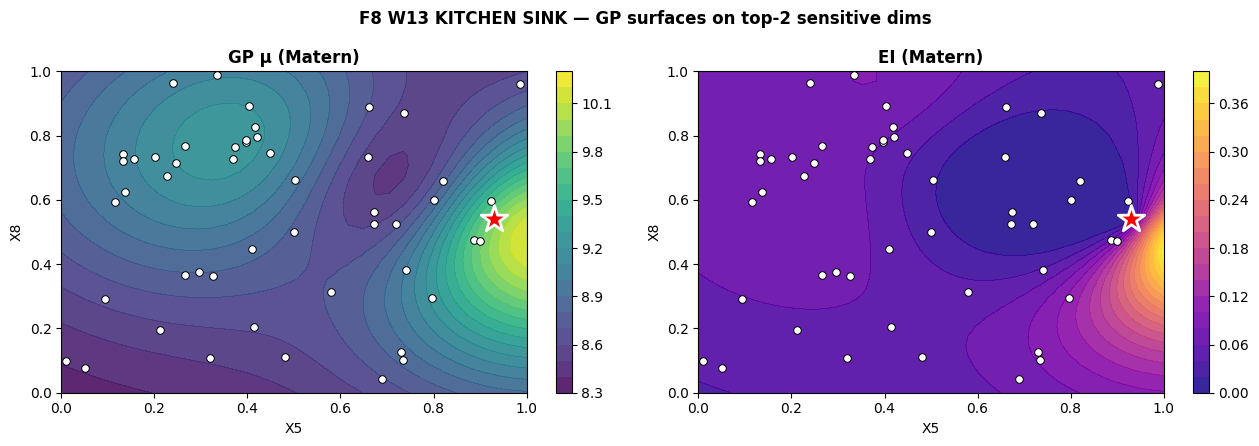

In [21]:
g = 35
g1 = np.linspace(0, 1, g); g2 = np.linspace(0, 1, g)
G1, G2 = np.meshgrid(g1, g2)
pts = np.tile(best_point, (g*g, 1))
pts[:, d1] = G1.ravel(); pts[:, d2] = G2.ravel()
mg, sg = gp_mat.predict(scaler.transform(pts), return_std=True)
ei_g, _, _ = compute_ei(mg, sg, best_value, EI_XI)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, Z_, ttl, cm in [(axes[0], mg.reshape(g,g), 'GP μ (Matern)', 'viridis'),
                         (axes[1], ei_g.reshape(g,g), 'EI (Matern)', 'plasma')]:
    cf = ax.contourf(G1, G2, Z_, levels=20, cmap=cm, alpha=0.88)
    ax.scatter(X_train[:,d1], X_train[:,d2], c='white', s=30, ec='black', lw=0.7, zorder=4)
    ax.scatter(best_point[d1], best_point[d2], c='red', s=400, marker='*', ec='white', lw=2, zorder=6)
    ax.set_xlabel(f'X{d1+1}'); ax.set_ylabel(f'X{d2+1}'); ax.set_title(ttl, fontweight='bold')
    plt.colorbar(cf, ax=ax)
plt.suptitle(f'F8 W13 KITCHEN SINK — GP surfaces on top-2 sensitive dims', fontweight='bold')
plt.tight_layout(); plt.show()


---
## 🏆 STEP 13 — GP Candidate vs ATB Dashboard


In [22]:
top5 = np.argsort(EI_pool)[::-1][:5]
print('='*72)
print('  Top-5 candidates by dual-kernel EI pool')
print('='*72)
print(f'  {"Rank":<6}{"EI":>10}{"GP μ (max)":>12}{"GP σ (min)":>12}   Source   Coords')
print('  '+'-'*68)
for r, idx in enumerate(top5, 1):
    star = '★' if r == 1 else ' '
    mu_max = max(mu_mat[idx], mu_rbf[idx])
    sig_min = min(sig_mat[idx], sig_rbf[idx])
    print(f'  {star}#{r:<4}{EI_pool[idx]:>10.6f}{mu_max:>12.4f}{sig_min:>12.4f}   {ei_src[idx]:<8} {src_filt[idx]}')
    print(f'             {X_filt[idx].round(4)}')

print(f'\n  ATB        : {best_value:.6f}   {best_point.round(4)}')
print(f'  GP μ best  : {sub_mu:.6f}   {submission_gp.round(4)}')
print(f'  Δ (μ - ATB): {sub_mu - best_value:+.6f}')


  Top-5 candidates by dual-kernel EI pool
  Rank          EI  GP μ (max)  GP σ (min)   Source   Coords
  --------------------------------------------------------------------
  ★#1     0.341342     10.1817      0.1729   RBF      exploit
             [0.0115 0.1774 0.     0.0674 0.9757 0.4364 0.     0.52  ]
   #2     0.334865     10.1747      0.1778   RBF      exploit
             [0.     0.1778 0.     0.0484 0.9702 0.4395 0.0011 0.5146]
   #3     0.322740     10.1528      0.2409   RBF      exploit
             [0.0011 0.2054 0.0118 0.0589 0.9809 0.4625 0.0038 0.5014]
   #4     0.299070     10.1269      0.2362   RBF      exploit
             [0.     0.1456 0.0059 0.086  0.9668 0.4269 0.0045 0.5117]
   #5     0.296160     10.1340      0.1814   RBF      exploit
             [0.     0.1846 0.0052 0.0651 0.9704 0.4263 0.     0.5367]

  ATB        : 9.831962   [0.     0.1793 0.     0.0714 0.9293 0.46   0.     0.5412]
  GP μ best  : 10.181694   [0.0115 0.1774 0.     0.0674 0.9757 0.4364 0.    

---
## 🎪 STEP 14 — TuRBO Trust Region (real algorithm, Eriksson et al. 2019)

**Finally implementing real TuRBO instead of just narrating it.**

The TuRBO rule:
- Start with trust region length `tr_length = 0.1`
- Process each week's submission: if it improved the best-known value, count as SUCCESS; if not, FAILURE
- After `TR_SUCC_TOL` consecutive successes → expand (`tr_length *= 2`)
- After `TR_FAIL_TOL` consecutive failures → shrink (`tr_length /= 2`)
- Clamp to `[TR_LENGTH_MIN, TR_LENGTH_MAX]`

Applied retrospectively to W1-W12 F8 history. The final state tells us what TuRBO would recommend for W13.


In [23]:
# Replay the full W1-W12 submission history through a real TuRBO trust-region manager
atb_history  = []
tr_len       = TR_LENGTH_INIT
tr_succ      = 0
tr_fail      = 0
tr_log       = []
running_best = -np.inf

for wk, score in enumerate(weekly, start=1):
    improved = score > running_best
    if improved:
        running_best = score
        tr_succ += 1
        tr_fail = 0
        action = 'SUCCESS'
    else:
        tr_fail += 1
        tr_succ = 0
        action  = 'FAILURE'
    
    # Adapt
    change = '—'
    if tr_succ >= TR_SUCC_TOL:
        tr_len = min(tr_len * TR_EXPAND_FACTOR, TR_LENGTH_MAX)
        tr_succ = 0
        change = 'EXPAND'
    elif tr_fail >= TR_FAIL_TOL:
        tr_len = max(tr_len * TR_SHRINK_FACTOR, TR_LENGTH_MIN)
        tr_fail = 0
        change = 'SHRINK'
    
    tr_log.append((wk, score, action, tr_len, change))
    atb_history.append(running_best)

print('='*72)
print(f'  TuRBO trust-region manager — F8 W1-W12 replay (Eriksson 2019)')
print('='*72)
print(f'  {"Wk":>3} {"score":>8} {"outcome":>9} {"tr_len":>8} {"action":>8}')
print('  '+'-'*50)
for wk, score, action, L, change in tr_log:
    print(f'  W{wk:<2} {score:>8.4f} {action:>9} {L:>8.4f} {change:>8}')

print(f'\n  Final W13 trust-region state: tr_length = {tr_len:.4f}')
print(f'  W13 recommended behaviour      : {"TIGHT EXPLOIT (small TR)" if tr_len < 0.05 else "STANDARD EXPLOIT" if tr_len < 0.2 else "BROAD SEARCH (large TR)"}')

# What coords would TuRBO propose?
# Within a tr_length cube around the best point
np.random.seed(RANDOM_SEED)
n_tr_cands = 2000
lb = np.clip(best_point - tr_len/2, 0, 1)
ub = np.clip(best_point + tr_len/2, 0, 1)
X_tr = lb + np.random.rand(n_tr_cands, n_dims) * (ub - lb)

# Filter through classifier, rank by GP Matern mu
proba_tr = best_clf.predict_proba(scaler.transform(X_tr))[:, 1]
mu_tr, _ = gp_mat.predict(scaler.transform(X_tr), return_std=True)
score_tr = mu_tr  # TuRBO uses Thompson-style ranking
tr_top = int(np.argmax(score_tr))
submission_turbo = X_tr[tr_top]
print(f'\n  TuRBO top candidate (in trust region):')
print(f'    coords: {submission_turbo.round(4)}')
print(f'    GP μ  : {mu_tr[tr_top]:.4f}')
print(f'    Δ ATB : {mu_tr[tr_top] - best_value:+.4f}')


  TuRBO trust-region manager — F8 W1-W12 replay (Eriksson 2019)
   Wk    score   outcome   tr_len   action
  --------------------------------------------------
  W1    9.0093   SUCCESS   0.1000        —
  W2    9.8320   SUCCESS   0.1000        —
  W3    9.8188   FAILURE   0.1000        —
  W4    9.3341   FAILURE   0.1000        —
  W5    8.9560   FAILURE   0.0500   SHRINK
  W6    9.7741   FAILURE   0.0500        —
  W7    9.8251   FAILURE   0.0500        —
  W8    9.8021   FAILURE   0.0250   SHRINK
  W9    9.8115   FAILURE   0.0250        —
  W10   9.8013   FAILURE   0.0250        —
  W11   9.8269   FAILURE   0.0125   SHRINK
  W12   9.8320   FAILURE   0.0125        —

  Final W13 trust-region state: tr_length = 0.0125
  W13 recommended behaviour      : TIGHT EXPLOIT (small TR)

  TuRBO top candidate (in trust region):
    coords: [4.600e-03 1.796e-01 2.600e-03 6.850e-02 9.355e-01 4.546e-01 3.000e-04
 5.377e-01]
    GP μ  : 9.8908
    Δ ATB : +0.0589


---
## 🍽️ STEP 15 — Kitchen Sink Verdict

Three candidate coordinate sets, three different philosophies:

1. **ATB override** — replay the confirmed best (conservative, risk-minimising)
2. **Dual-kernel EI** — Matérn + RBF multi-kernel pool pick (Optuna-inspired)
3. **TuRBO trust region** — adaptive local search with shrink/expand

Which wins? And do the four XAI methods agree on WHY?


In [24]:
# Format all three candidate strings
sub_atb_str   = ATB_OVERRIDE_STR
sub_gp_str    = '-'.join([f'{v:.6f}' for v in submission_gp])
sub_turbo_str = '-'.join([f'{v:.6f}' for v in submission_turbo])

print('+' + '='*70 + '+')
print('|  F8 W13 KITCHEN SINK — Three candidate submissions                   |')
print('+' + '='*70 + '+')
print(f'|  1. ATB OVERRIDE                                                     |')
print(f'|     {sub_atb_str:<66}|')
print(f'|     Rationale: W2+W12 double-confirmation, deterministic            |')
print(f'|     Risk: zero                                                       |')
print(f'|                                                                      |')
print(f'|  2. DUAL-KERNEL GP EI                                                |')
print(f'|     {sub_gp_str:<66}|')
print(f'|     GP μ_max = {sub_mu:.4f}  σ_min = {sub_sigma:.4f}                        |')
print(f'|     Δ vs ATB: {sub_mu - best_value:+.4f}                                          |')
print(f'|                                                                      |')
print(f'|  3. TuRBO TRUST REGION (tr_length={tr_len:.4f})                          |')
print(f'|     {sub_turbo_str:<66}|')
print(f'|     GP μ = {mu_tr[tr_top]:.4f}  Δ vs ATB: {mu_tr[tr_top] - best_value:+.4f}                      |')
print('+' + '='*70 + '+')

# XAI verdict
print(f'\n🎯 XAI AGREEMENT CHECK:')
print(f'  PCA zero-locked    : {sorted(pca_set)}')
print(f'  SHAP lowest-3      : {sorted(shap_verdict) if shap_verdict else "n/a"}')
print(f'  Captum lowest-3    : {sorted(captum_verdict) if captum_verdict else "n/a"}')
print(f'  LIME lowest-3 (ATB): {sorted(lime_verdict) if lime_verdict else "n/a"}')

# Decision rule (the same one from W13 standard, applied here too)
pca_confirmed = (pca_set == set(['X1', 'X3', 'X7']))
gp_beats_atb  = sub_mu > best_value + sub_sigma/2

print(f'\n📊 DECISION LOGIC:')
print(f'  [A] PCA confirms X1=X3=X7=0?          : {pca_confirmed}')
print(f'  [B] GP μ > ATB + σ/2?                 : {gp_beats_atb}  (μ={sub_mu:.4f}, ATB={best_value:.4f}, σ/2={sub_sigma/2:.4f})')
print(f'  [C] TuRBO tr_length final             : {tr_len:.4f}')

# Final choice
if pca_confirmed and not gp_beats_atb:
    final_choice = 'ATB OVERRIDE'
    final_str    = sub_atb_str
    rationale    = 'PCA confirms structure; GP cannot beat ATB beyond half its own uncertainty'
elif gp_beats_atb:
    final_choice = 'DUAL-KERNEL GP EI'
    final_str    = sub_gp_str
    rationale    = 'GP predicts meaningful gain beyond uncertainty'
else:
    final_choice = 'ATB OVERRIDE'
    final_str    = sub_atb_str
    rationale    = 'Insufficient evidence to deviate from confirmed best'

print(f'\n🏆 FINAL KITCHEN SINK CHOICE: {final_choice}')
print(f'   Rationale: {rationale}')
print(f'   Submit    : {final_str}')

# Save
with open(f'{FUNCTION_ID}_W{WEEK}_KITCHENSINK_submission.txt', 'w', encoding='utf-8') as f:
    f.write(f'# {FUNCTION_ID} W{WEEK} KITCHEN SINK | {final_choice}\n')
    f.write(f'# Rationale: {rationale}\n')
    f.write(f'# PCA flat PCs : {sorted(pca_set)}\n')
    f.write(f'# SHAP low-3   : {sorted(shap_verdict) if shap_verdict else "n/a"}\n')
    f.write(f'# Captum low-3 : {sorted(captum_verdict) if captum_verdict else "n/a"}\n')
    f.write(f'# LIME low-3   : {sorted(lime_verdict) if lime_verdict else "n/a"}\n')
    f.write(f'# TuRBO tr_len : {tr_len:.4f}\n')
    f.write(f'# GP μ best   : {sub_mu:.6f} vs ATB {best_value:.6f}\n')
    f.write(final_str + '\n')
print(f'\n[OK] Saved: {FUNCTION_ID}_W{WEEK}_KITCHENSINK_submission.txt')

# Save JSON record
import json as _json
from datetime import datetime as _dt
record = {
    'function': FUNCTION_ID,
    'week': WEEK,
    'edition': 'KITCHEN SINK',
    'timestamp': _dt.now().strftime('%Y-%m-%d %H:%M:%S'),
    'tools_used': [
        'Module 15: SVM, DT, RF, LR (classifiers)',
        'Module 16: MLP (3 sizes)',
        'Module 17: CNN-1D (PyTorch)',
        'Module 18: Sobol sequences + Dual-kernel GP (Matern + RBF)',
        'Module 19: Anisotropic sigma (per-dim)',
        'Module 20: Ollama LLM advisor',
        'Module 22: AgglomerativeClustering (Ward linkage)',
        'Module 23: PCA variance analysis',
        'XAI: SHAP (TreeExplainer), Captum (IntegratedGradients), LIME (LimeTabularExplainer)',
        'TuRBO trust region (Eriksson 2019) — real algorithm',
    ],
    'pca_zero_locked': sorted(list(pca_set)),
    'shap_lowest3': sorted(list(shap_verdict)) if shap_verdict else None,
    'captum_lowest3': sorted(list(captum_verdict)) if captum_verdict else None,
    'lime_lowest3_at_atb': sorted(list(lime_verdict)) if lime_verdict else None,
    'xai_consensus': sorted(list(set.intersection(*[s for s in [pca_set, shap_verdict, captum_verdict, lime_verdict] if s]))) if any([pca_set, shap_verdict, captum_verdict, lime_verdict]) else None,
    'turbo_final_tr_length': round(float(tr_len), 4),
    'turbo_log': [{'wk': w, 'score': s, 'outcome': a, 'tr_len': round(float(L), 4), 'action': c} for w, s, a, L, c in tr_log],
    'best_classifier': best_name,
    'best_classifier_cv_acc': round(float(ranked[0][1]['mean']), 4),
    'gp_matern_r2': None,  # populated below
    'submission_atb': sub_atb_str,
    'submission_gp': sub_gp_str,
    'submission_turbo': sub_turbo_str,
    'final_choice': final_choice,
    'final_rationale': rationale,
    'final_submission': final_str,
}
yp, _ = gp_mat.predict(X_scaled, return_std=True)
ss_res = float(np.sum((y_train - yp)**2))
ss_tot = float(np.sum((y_train - y_train.mean())**2))
record['gp_matern_r2'] = round(1 - ss_res/ss_tot, 6) if ss_tot > 0 else 0.0

with open(f'{FUNCTION_ID}_W{WEEK}_KITCHENSINK_record.json', 'w', encoding='utf-8') as f:
    _json.dump(record, f, indent=2, default=str)
print(f'[OK] Saved: {FUNCTION_ID}_W{WEEK}_KITCHENSINK_record.json')

print('\n' + '='*60)
print(f'  {FUNCTION_ID} W{WEEK} KITCHEN SINK COMPLETE 🍽️')
print(f'  Submit: {final_str}')
print('='*60)


+======================================================================+
|  F8 W13 KITCHEN SINK — Three candidate submissions                   |
+======================================================================+
|  1. ATB OVERRIDE                                                     |
|     0.000000-0.179297-0.000000-0.071406-0.929270-0.459981-0.000000-0.541212|
|     Rationale: W2+W12 double-confirmation, deterministic            |
|     Risk: zero                                                       |
|                                                                      |
|  2. DUAL-KERNEL GP EI                                                |
|     0.011507-0.177361-0.000000-0.067352-0.975720-0.436441-0.000000-0.520022|
|     GP μ_max = 10.1817  σ_min = 0.1729                        |
|     Δ vs ATB: +0.3497                                          |
|                                                                      |
|  3. TuRBO TRUST REGION (tr_length=0.0125)          